In [3]:
import pandas as pd

df = pd.read_csv("../data/Reviews.csv")

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
df.shape
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [7]:
df = df[['ProductId','Score','Text','Time']]
df.head()

df.isnull().sum()

ProductId    0
Score        0
Text         0
Time         0
dtype: int64

In [8]:
df['Score'].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

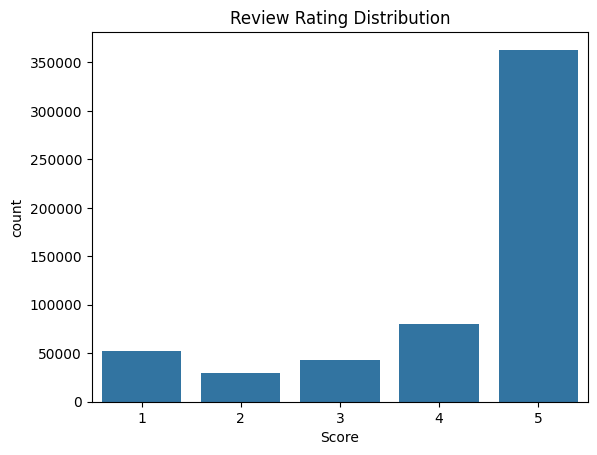

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Score', data=df)

plt.title("Review Rating Distribution")
plt.show()

In [10]:
df = df.sample(50000, random_state=42)
df.shape

(50000, 4)

In [12]:
def get_sentiment(score):
    
    if score <= 2:
        return "Negative"
    
    elif score == 3:
        return "Neutral"
    
    else:
        return "Positive"


df["Sentiment"] = df["Score"].apply(get_sentiment)

df.head()

df["Sentiment"].value_counts()

Sentiment
Positive    39105
Negative     7104
Neutral      3791
Name: count, dtype: int64

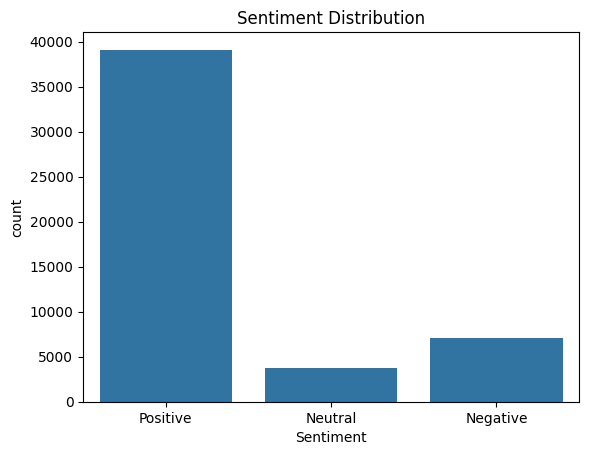

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Sentiment", data=df)

plt.title("Sentiment Distribution")
plt.show()

In [14]:
df[['Score','Sentiment','Text']].head(10)

,Score,Sentiment,Text
165256,5,Positive,Having tried a couple of other brands of glute...
231465,5,Positive,My cat loves these treats. If ever I can't fin...
427827,3,Neutral,A little less than I expected. It tends to ha...
433954,2,Negative,"First there was Frosted Mini-Wheats, in origin..."
70260,5,Positive,and I want to congratulate the graphic artist ...
49866,4,Positive,Please add more Pineapple flavor to your packa...
551047,5,Positive,I absolutely love Yorkshire tea and am so glad...
18983,5,Positive,I have such a hard time finding loose tea loca...
138968,4,Positive,"Previously, I've attempted a recipe with white..."
36352,5,Positive,I make pancakes or waffles every Saturday morn...


In [16]:
df = df[df['Text'].str.len() > 20]
df.shape

(50000, 5)

In [17]:
df.to_csv("../data/processed_reviews.csv", index=False)

In [18]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\263299\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\263299\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\263299\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [5]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import pandas as pd

In [6]:
# lemmatize words
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z ]", "", text)

    # tokenize words
    words = text.split()

    # remove stopwords
    stop_words = set(stopwords.words("english"))
    words = [word for word in words if word not in stop_words]

    # lemmatize words
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

df = pd.read_csv("../data/processed_reviews.csv")
df["Cleaned_Text"] = df["Text"].apply(clean_text)

In [14]:
df = df[df["Cleaned_Text"].str.len() > 0]
df.shape
df.head()
df.to_csv("../data/preprocessed_reviews.csv", index=False)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["Cleaned_Text"])
y = df["Sentiment"]

In [18]:
X.shape
vectorizer.get_feature_names_out()[:20]
len(vectorizer.get_feature_names_out())

5000

In [21]:
X[0]
X[0].toarray()
y.value_counts()

Sentiment
Positive    39105
Negative     7104
Neutral      3791
Name: count, dtype: int64

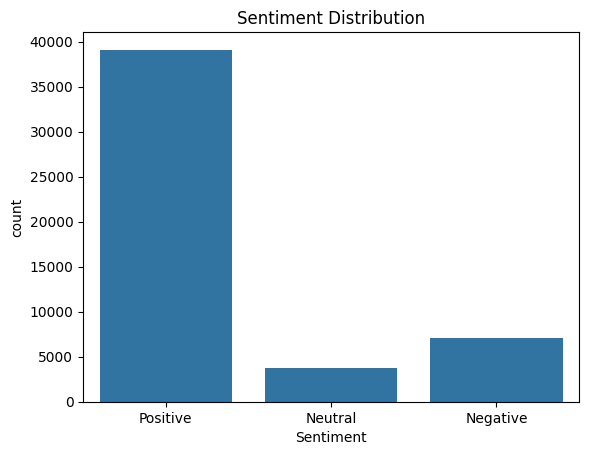

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Sentiment Distribution")
plt.show()

In [23]:
import pickle

pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

In [24]:
print(X.shape)
print(y.value_counts())

(50000, 5000)
Sentiment
Positive    39105
Negative     7104
Neutral      3791
Name: count, dtype: int64
